In [ ]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library(CCA)
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)

theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

In [126]:
delta_chromatin = read.table(file = "../data/5_chromatin_delta_usage_per_gene", sep = "\t", header = T, check.names = FALSE) %>% column_to_rownames("gene_id")
lfc_isoforms = read.table(file = "../data/7_mature_rna_isoform_log2fc_per_gene.tsv", sep = "\t", header = T) %>% column_to_rownames("gene_id")
shared_genes = unique(sort(intersect(rownames(delta_chromatin), rownames(lfc_isoforms))))

chrom_cols <- c("promoter-accessible", "intragenic-accessible",
                "co-accessible", "fully-nucleosomal", "fully-accessible")
iso_cols   <- c("lfc_canonical", "lfc_downstream", "lfc_antisense")

df <- cbind(delta_chromatin[shared_genes, chrom_cols], lfc_isoforms[shared_genes,iso_cols])

df[is.na(df)] = 0


df_scaled <- df %>% mutate(across(all_of(c(chrom_cols, iso_cols)), scale))

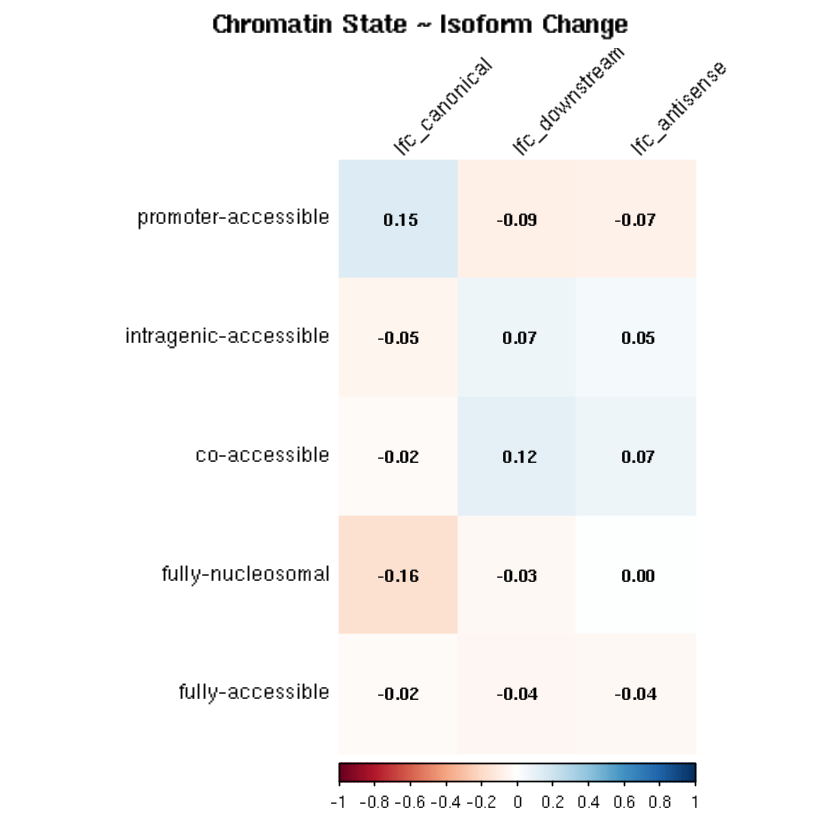

In [52]:
library(corrplot)

cor_mat <- cor(
  df %>% select(all_of(chrom_cols)),
  df %>% select(all_of(iso_cols)),
  use = "pairwise.complete.obs"
)

corrplot(cor_mat, method = "color", addCoef.col = "black",
         tl.col = "black", tl.srt = 45, number.cex = 0.8,
         cl.pos = "b", title = "Chromatin State ~ Isoform Change",
         mar = c(0, 0, 2, 0))

In [69]:

df_complete <- df_scaled %>% drop_na(all_of(c(chrom_cols, iso_cols)))

X_chrom <- df_complete %>% dplyr::select(all_of(chrom_cols)) %>% as.matrix()
Y_iso   <- df_complete %>% dplyr::select(all_of(iso_cols))   %>% as.matrix()

cca_fit <- cc(X_chrom, Y_iso)
cca_fit$cor



# Chromatin loadings on each canonical variate
chrom_loadings <- as.data.frame(cca_fit$scores$corr.X.xscores)
chrom_loadings$chromatin <- chrom_cols

# Isoform loadings
iso_loadings <- as.data.frame(cca_fit$scores$corr.Y.yscores)
iso_loadings$isoform <- iso_cols

library(ggrepel)

load_df <- bind_rows(
  chrom_loadings %>%
    dplyr::select(name = chromatin, CV1 = V1, CV2 = V2) %>%
    dplyr::mutate(type = "Chromatin"),
  iso_loadings %>%
    dplyr::select(name = isoform, CV1 = V1, CV2 = V2) %>%
    dplyr::mutate(type = "Isoform")
)

ggplot(load_df, aes(x = CV1, y = CV2, color = type, label = name)) +
  geom_segment(aes(xend = 0, yend = 0), arrow = arrow(ends = "first", length = unit(0.2, "cm")),
               linewidth = 0.8) +
  geom_label_repel(size = 3.5, max.overlaps = 20) +
  scale_color_manual(values = c("Chromatin" = "darkorange", "Isoform" = "steelblue")) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey60") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey60") +
  labs(x = paste0("CV1 (r = ", round(cca_fit$cor[1], 3), ")"),
       y = paste0("CV2 (r = ", round(cca_fit$cor[2], 3), ")"),
       title = "CCA: Chromatin-Isoform Co-regulation",
       color = "") +
  theme_minimal()

In [82]:
set.seed(42)
n_perm <- 999
perm_cors <- replicate(n_perm, {
  Y_perm <- Y_iso[sample(nrow(Y_iso)), ]
  cc(X_chrom, Y_perm)$cor[1]
})

# p-value
mean(perm_cors >= cca_fit$cor[1])

[1] 0

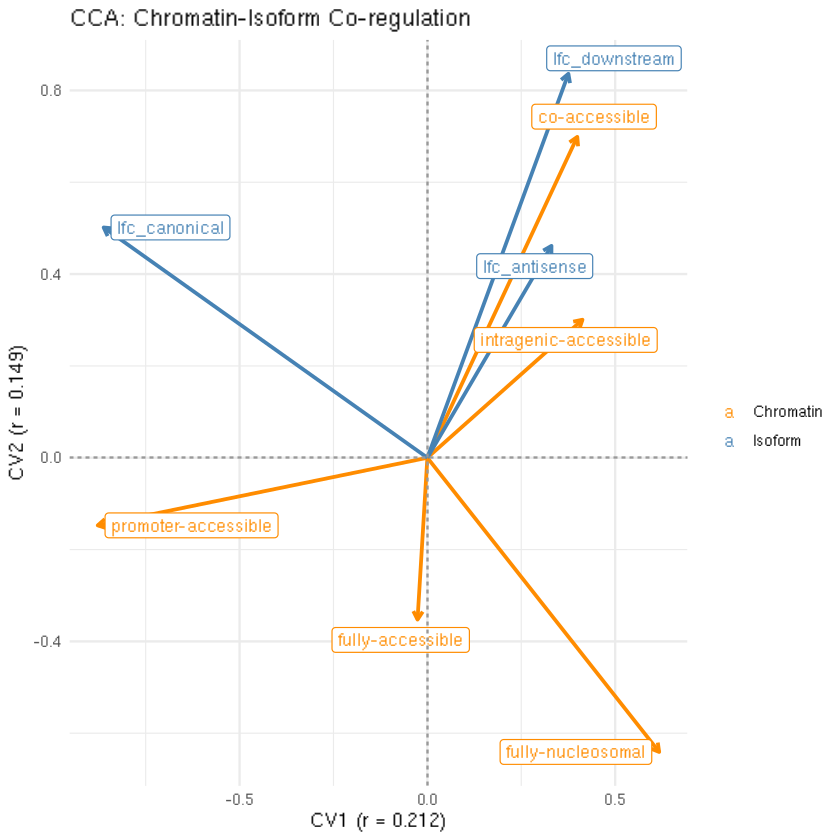

## find overlaps between isoform change and chromatin change

In [128]:
log2fc_iso = read.table("../data/7_mature_rna_joint_isoform_DE_vs_gene_de_by_expr.tsv", header = T, sep = "\t")

In [331]:
chrom_usage<- read.table("../data/4_chromatin_state_usage.tsv", sep = "\t", header = TRUE, row.names = 1)
delta_chromatin = read.table(file = "../data/5_chromatin_delta_usage_per_gene", sep = "\t", header = T, check.names = FALSE) %>% column_to_rownames("gene_id")


In [362]:
lfc_isoforms = read.table(file = "../data/7_mature_rna_isoform_log2fc_per_gene.tsv", sep = "\t", header = T) %>% column_to_rownames("gene_id")
shared_genes = unique(sort(intersect(rownames(delta_chromatin), rownames(lfc_isoforms))))

chrom_level = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible')
iso_cols   <- c("lfc_canonical", "lfc_downstream", "lfc_antisense")

df <- cbind(delta_chromatin[shared_genes,], lfc_isoforms[shared_genes,iso_cols])
df$class<- factor(df$class, levels = c('low', 'medium', 'high'))
df[is.na(df)] = 0

df2<- chrom_usage %>%
    mutate(WT_mean = rowMeans(across(c('WT_rep1', 'WT_rep2'))),
          MUT_mean = rowMeans(across(c('MUT_rep1', 'MUT_rep2'))),
          chrom_state = str_split_i(rownames(.), ':', 2),
          geneid = str_split_i(rownames(.), ':', 1)
          ) %>% 
    dplyr::select(WT_mean, MUT_mean, chrom_state, geneid) %>% 
    pivot_wider(names_from = chrom_state, values_from = c(WT_mean, MUT_mean)) %>% 
    column_to_rownames("geneid")

df2[is.na(df2)] = 0

df<- cbind(df, df2[rownames(df), ])

In [378]:
dominance_threshold = 0.5
WT_usage = 0.1
MUT_usage = 0.1
mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
names(mcol) <- c("low", "medium", "high")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


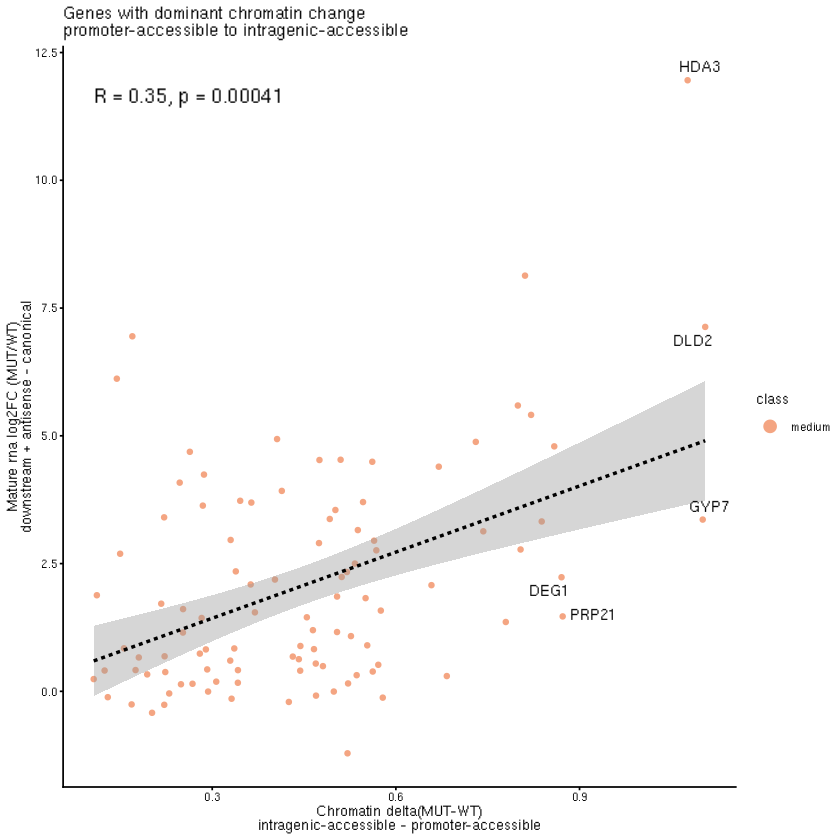

In [399]:
down_state = c('promoter-accessible')
up_state = c('intragenic-accessible')
WT_state = paste0('WT_mean_', down_state)
MUT_state = paste0('MUT_mean_', up_state)

candidates <- df %>%
    filter(
        if_all(all_of(WT_state),  ~ .x > WT_usage),
        if_all(all_of(MUT_state),  ~ .x > MUT_usage),
        if_all(all_of(down_state), ~ .x < 0),
        if_all(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_downstream + lfc_antisense - lfc_canonical,
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(shift_score)) %>%
    filter(dominance >= dominance_threshold) %>% filter(class == 'medium')

top_3<- candidates %>% head(n = 5)

candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_point(aes(color = class), size = 1) +
    labs(x = 'Chromatin delta(MUT-WT)\nintragenic-accessible - promoter-accessible', 
         y = 'Mature rna log2FC (MUT/WT)\ndownstream + antisense - canonical',
         title = 'Genes with dominant chromatin change\npromoter-accessible to intragenic-accessible') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman",
             label.x.npc = "left", label.y.npc = "top", size = 4) +
    theme_classic(base_size=8) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel(
        data = top_3,
        aes(label = geneid),
        size = 3, max.overlaps = 12
    ) +
    guides(color = guide_legend(override.aes = list(size = 3)))

ggsave('../figures/Supp_correlation_chromain_isoform_promoter_accessible_down_intragenic_accessible_up.pdf', width = 4, height = 3)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


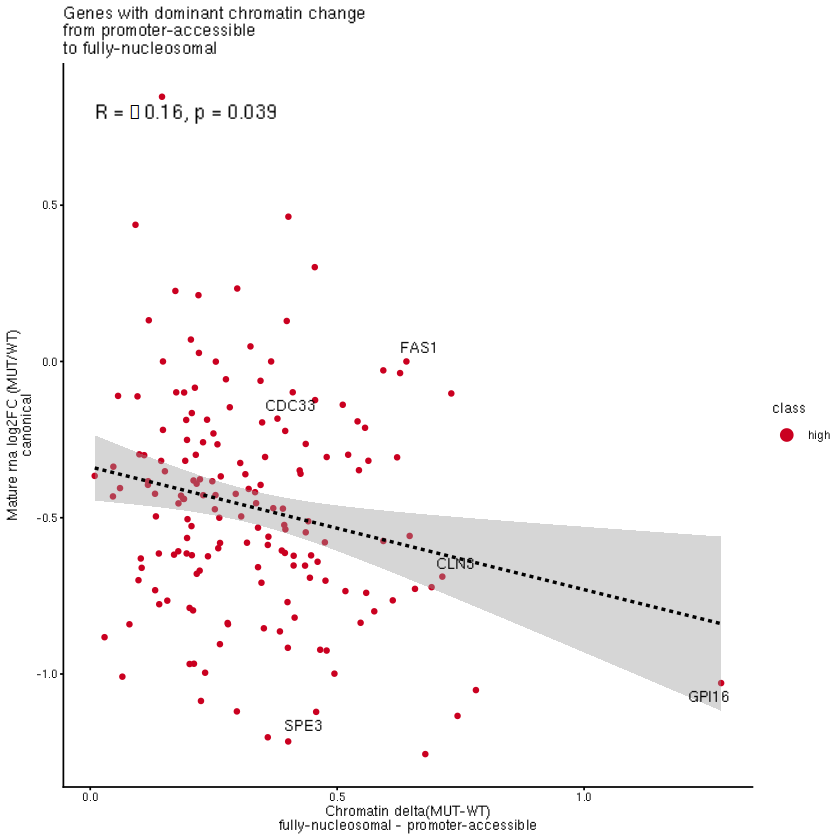

In [432]:
down_state = c('promoter-accessible')
up_state = c('fully-nucleosomal')
WT_state = paste0('WT_mean_', down_state)
MUT_state = paste0('MUT_mean_', up_state)

candidates <- df %>%
    filter(
        if_all(all_of(down_state), ~ .x < 0),
        if_all(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_canonical,
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(dominance)) %>%
    filter(dominance >= dominance_threshold) %>% filter(class == 'high')

top_3<- candidates %>% head(n = 5)

candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_point(aes(color = class), size = 1) +
    labs(x = 'Chromatin delta(MUT-WT)\nfully-nucleosomal - promoter-accessible', 
         y = 'Mature rna log2FC (MUT/WT)\ncanonical',
         title = 'Genes with dominant chromatin change\nfrom promoter-accessible\nto fully-nucleosomal') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman",
             label.x.npc = "left", label.y.npc = "top", size = 4) +
    theme_classic(base_size=8) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel(
        data = top_3,
        aes(label = geneid),
        size = 3, max.overlaps = 12
    ) +
    guides(color = guide_legend(override.aes = list(size = 3)))

ggsave('../figures/Supp_correlation_chromain_isoform_promoter_accessible_down_fully-nucleosomal_up.pdf', width = 4, height = 3)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


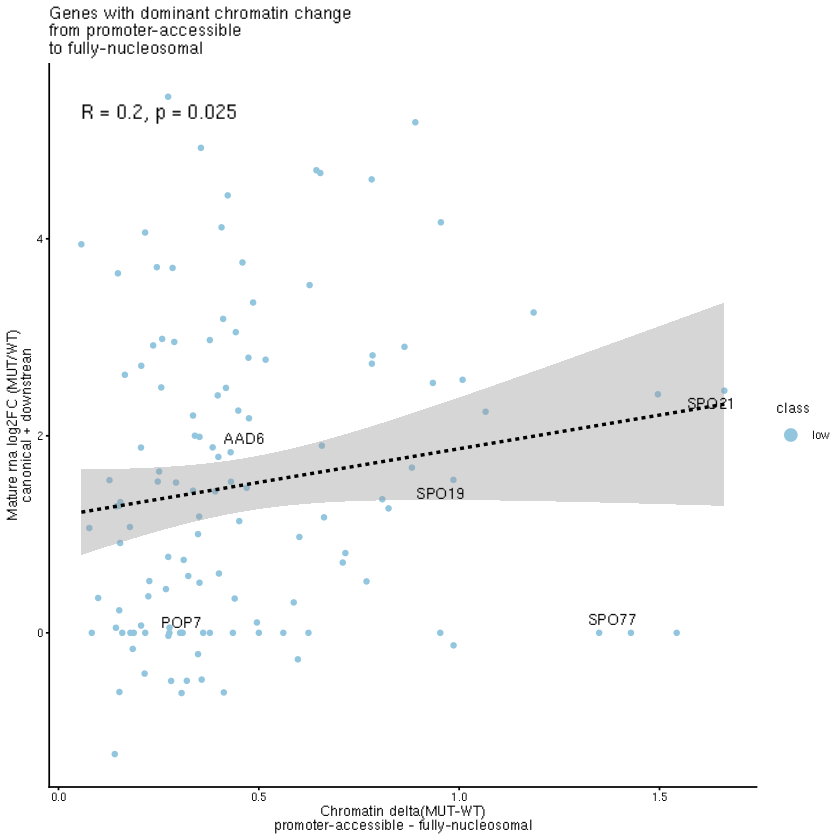

In [436]:
down_state = c('fully-nucleosomal')
up_state = c('promoter-accessible')

WT_state = paste0('WT_mean_', down_state)
MUT_state = paste0('MUT_mean_', up_state)

candidates <- df %>%
    filter(
        if_any(all_of(down_state), ~ .x < 0),
        if_any(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_canonical + lfc_downstream, 
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(dominance)) %>%
    filter(dominance >= dominance_threshold) %>% filter(class == 'low')

top_3<- candidates %>% head(n = 5)

candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_point(aes(color = class), size = 1) +
    labs(x = 'Chromatin delta(MUT-WT)\npromoter-accessible - fully-nucleosomal', 
         y = 'Mature rna log2FC (MUT/WT)\ncanonical + downstrean',
         title = 'Genes with dominant chromatin change\nfrom promoter-accessible\nto fully-nucleosomal') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman",
             label.x.npc = "left", label.y.npc = "top", size = 4) +
    theme_classic(base_size=8) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel(
        data = top_3,
        aes(label = geneid),
        size = 3, max.overlaps = 12
    ) +
    guides(color = guide_legend(override.aes = list(size = 3)))

ggsave('../figures/Supp_correlation_chromain_isoform_fully-nucleosomal_down_promoter_accessible_up.pdf', width = 4, height = 3)

In [216]:
tpm<- read.table('../data/7_mature_rna_tss_tpm.tsv', header=T, sep="\t", row.names=1, check.names = FALSE)

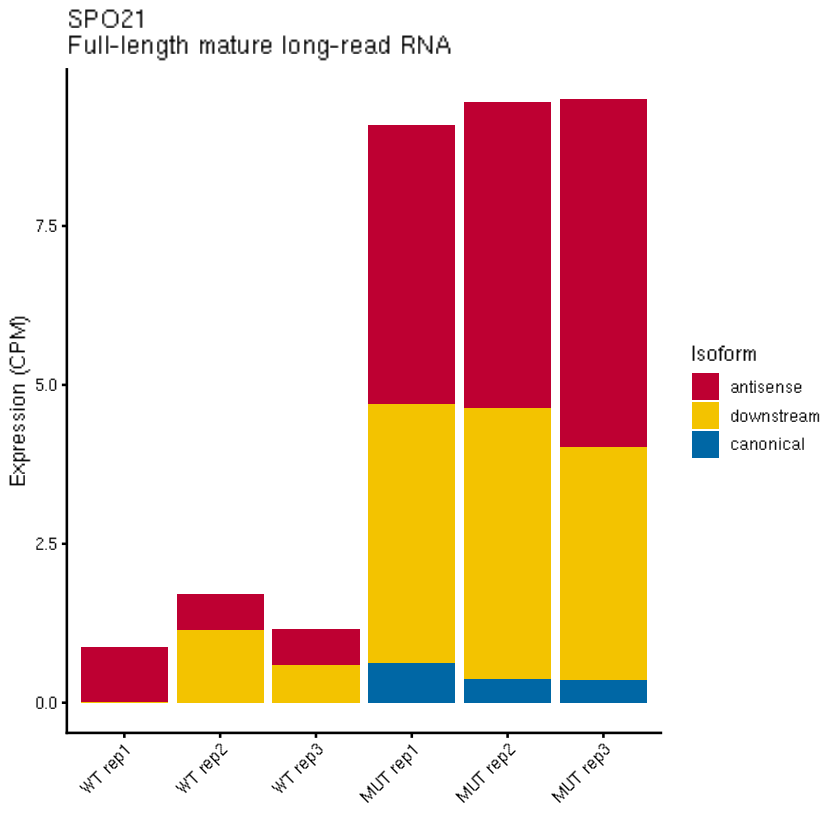

In [444]:
plot_expr_telo(tpm, "SPO21")
ggsave('../figures/Supp_SPO21_cpm.pdf', width = 4, height = 3.5)

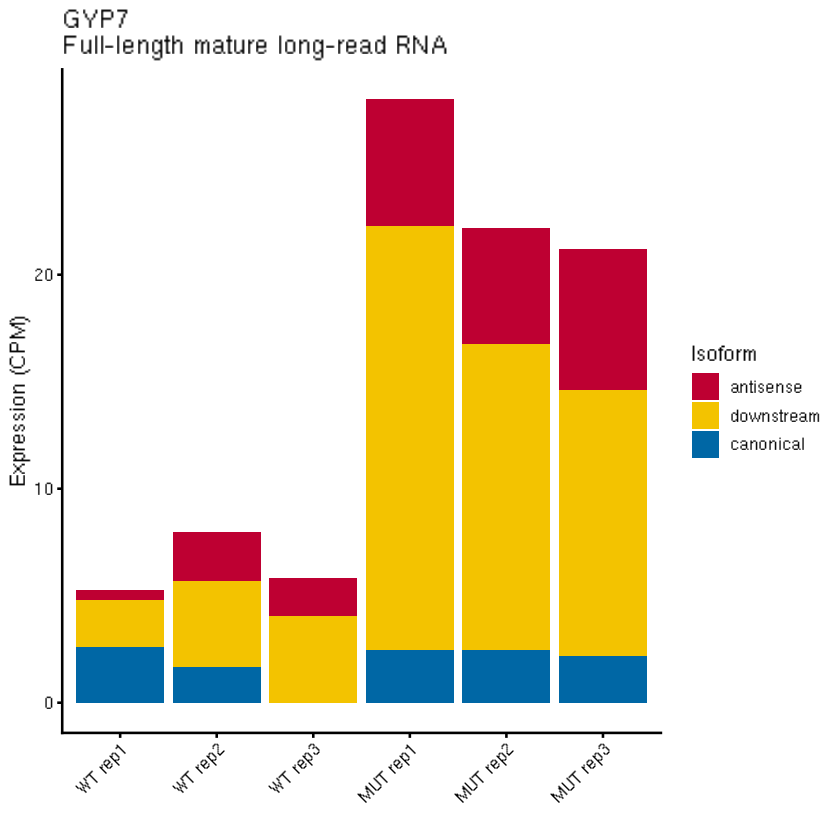

In [445]:
plot_expr_telo(tpm, "GYP7")
ggsave('../figures/Supp_GYP7_cpm.pdf', width = 4, height = 3.5)

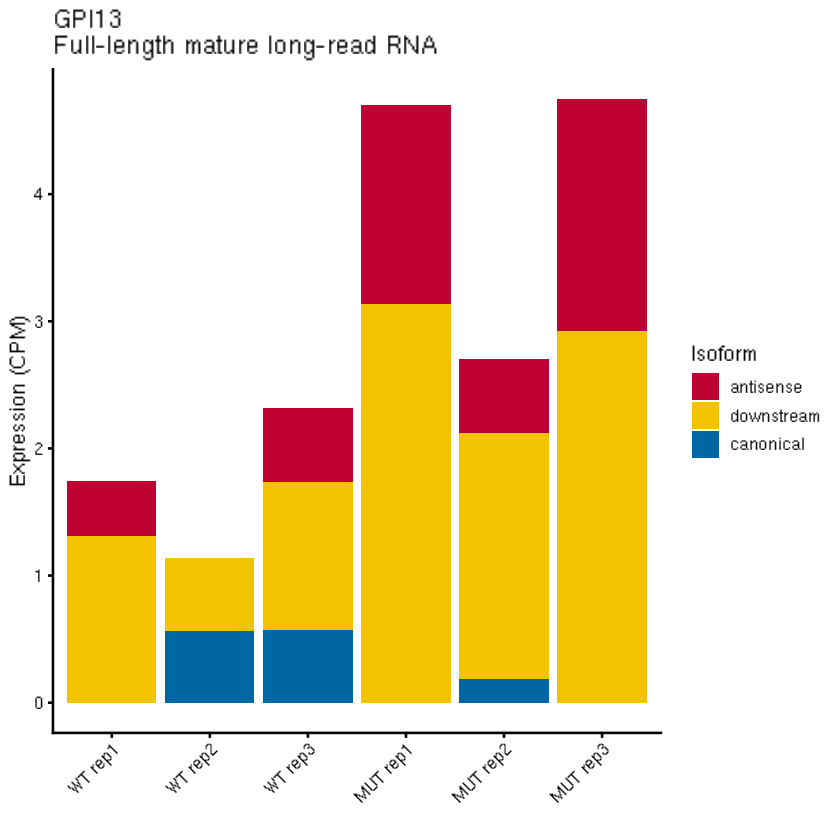

In [439]:
plot_expr_telo(tpm, "GPI13")
ggsave('../figures/Supp_GPI13_cpm.pdf', width = 4, height = 3.5)

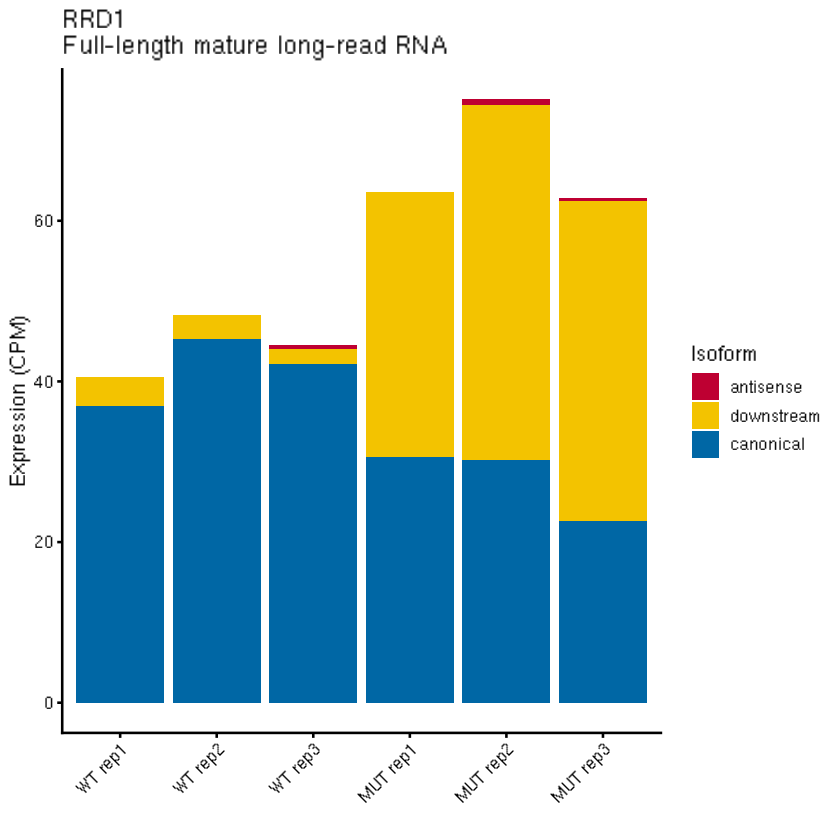

In [440]:
plot_expr_telo(tpm, "RRD1")
ggsave('../figures/Supp_RRD1_cpm.pdf', width = 4, height = 3.5)